In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 0 — Install Dependencies

In [2]:
# Install required libraries
!pip install deepface mtcnn --quiet
print('✅ deepface + mtcnn installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.9 MB/s eta 0:00:00
✅ deepface + mtcnn installed


## Step 1 — laod the data

In [3]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_PATH  = "/content/drive/MyDrive/pp_v2/112aligned_faces"

## Step 2 — set up

In [4]:
# ── Image / Training ──────────────────────────────────────────────────────────
IMAGE_SIZE    = (112, 112)   # ArcFace's native input
BATCH_SIZE    = 32
VAL_SPLIT     = 0.2
SEED          = 42

# ── Training hyper-params ─────────────────────────────────────────────────────
LR_PHASE1     = 1e-4         # Head-only warmup — can be aggressive
LR_PHASE2     = 5e-6         # Fine-tune — tiny, careful nudges
EPOCHS_P1     = 20
EPOCHS_P2     = 15
PATIENCE      = 5            # EarlyStopping patience

print('✅ Configuration set')

✅ Configuration set


## Step 3 — Dataset Audit

In [5]:
import os
from collections import Counter

print('=== Aligned Dataset Audit ===\n')
class_folders = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

counts = {}
total_images = 0
for folder in class_folders:
    n = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, folder))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    counts[folder] = n
    total_images  += n
    print(f'  {folder:<30s}: {n} images')

NUM_CLASSES = len(class_folders)
print(f'\nTotal classes : {NUM_CLASSES}')
print(f'Total images  : {total_images}')
print(f'Avg per class : {total_images / NUM_CLASSES:.1f}')
print(f'Min per class : {min(counts.values())}')
print(f'Max per class : {max(counts.values())}')

=== Aligned Dataset Audit ===

  Lita                          : 126 images
  Makara                        : 126 images
  Rathana                       : 125 images
  Xuning                        : 125 images
  chesda                        : 125 images
  chotakna                      : 125 images
  danith                        : 125 images
  davit                         : 126 images
  deth                          : 126 images
  eun woo                       : 126 images
  iu                            : 126 images
  jay                           : 126 images
  jennie                        : 126 images
  khikhe                        : 125 images
  linghe                        : 125 images
  meng                          : 126 images
  mengheang                     : 126 images
  mony                          : 126 images
  nika                          : 126 images
  odom                          : 126 images
  ruohan                        : 126 images
  sakura                

## Step 4 — Data Pipeline with Safe Augmentation

> **Safe augmentations for faces:**  
> ✅ Horizontal flip | ✅ ±5° rotation | ✅ ±10% brightness  
> ❌ Vertical flip | ❌ Heavy crop | ❌ Extreme color distortion

In [6]:
import tensorflow as tf
import numpy as np

# ── Normalization: ArcFace standard ──────────────────────────────────────────
def normalize_arcface(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 128.0  # Range: roughly [-1, 1]
    return image, label

# ── Safe face augmentation ────────────────────────────────────────────────────
def augment_face(image, label):
    """Apply only face-safe augmentations."""
    # Horizontal flip — faces are mirror-symmetric
    image = tf.image.random_flip_left_right(image)
    # Slight brightness shift (±10%)
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Clip to valid range after brightness shift
    image = tf.clip_by_value(image, -1.0, 1.0)
    # Slight rotation ±5° — implemented via shear approximation
    # (full rotation requires tf.keras.layers.RandomRotation in the model)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# ── Build datasets from aligned folder ───────────────────────────────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

CLASS_NAMES = train_ds_raw.class_names

# ── Apply preprocessing + augmentation (train only) ──────────────────────────
train_ds = (
    train_ds_raw
    .map(normalize_arcface, num_parallel_calls=AUTOTUNE)
    .map(augment_face,      num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(normalize_arcface, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f'✅ Pipeline ready — {len(CLASS_NAMES)} classes')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Classes    : {CLASS_NAMES}')

Found 4024 files belonging to 32 classes.
Using 3220 files for training.
Found 4024 files belonging to 32 classes.
Using 804 files for validation.
✅ Pipeline ready — 32 classes
  Batch size : 32
  Classes    : ['Lita', 'Makara', 'Rathana', 'Xuning', 'chesda', 'chotakna', 'danith', 'davit', 'deth', 'eun woo', 'iu', 'jay', 'jennie', 'khikhe', 'linghe', 'meng', 'mengheang', 'mony', 'nika', 'odom', 'ruohan', 'sakura', 'samoal', 'senghut', 'simvin', 'sinta', 'sivmeng', 'sunghoon', 'tra', 'vorak', 'vuth', 'ziyu']


In [7]:
# ── Verify normalization range ────────────────────────────────────────────────
for imgs, _ in train_ds.take(1):
    print('Normalization check:')
    print(f'  Min  : {imgs.numpy().min():.4f}  (target ≈ −1.0)')
    print(f'  Max  : {imgs.numpy().max():.4f}  (target ≈  1.0)')
    print(f'  Mean : {imgs.numpy().mean():.4f}  (expect near 0)')
    print(f'  dtype: {imgs.dtype}')
    assert imgs.numpy().min() >= -1.1 and imgs.numpy().max() <= 1.1, \
        '❌ Pixel range out of bounds — check normalization!'
    print('✅ Normalization OK')

Normalization check:
  Min  : -1.0000  (target ≈ −1.0)
  Max  : 0.9618  (target ≈  1.0)
  Mean : -0.1885  (expect near 0)
  dtype: <dtype: 'float32'>
✅ Normalization OK


## Step 6 — Load Pretrained ArcFace

In [8]:
from deepface import DeepFace

arcface_client = DeepFace.build_model('ArcFace')
base_model      = arcface_client.model

print('✅ ArcFace loaded')
print(f'  Input  : {base_model.input_shape}')
print(f'  Output : {base_model.output_shape}   ← 512-dim embedding')
print(f'  Layers : {len(base_model.layers)}')
print()
print('Last 5 layers:')
for layer in base_model.layers[-5:]:
    try:
        shape = layer.output.shape
    except Exception:
        shape = 'n/a'
    print(f'  {layer.name:<45s}  {shape}')

26-05-22 07:44:09 - Directory /root/.deepface has been created
26-05-22 07:44:09 - Directory /root/.deepface/weights has been created
26-05-22 07:44:11 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:00<00:00, 441MB/s] 


✅ ArcFace loaded
  Input  : (None, 112, 112, 3)
  Output : (None, 512)   ← 512-dim embedding
  Layers : 162

Last 5 layers:
  batch_normalization                            (None, 7, 7, 512)
  dropout                                        (None, 7, 7, 512)
  flatten                                        (None, 25088)
  dense                                          (None, 512)
  embedding                                      (None, 512)


## Step 7 — ArcFace Margin Layer

This replaces the plain `Dense + Softmax` head with an **Angular Margin** layer —
the core innovation of ArcFace. It pushes embeddings of the *same* person closer
together and embeddings of *different* people further apart on the hypersphere.

Parameters:
- **`s` (scale)** = 64 — standard for 112×112 models  
- **`m` (margin)** = 0.55 — angular gap in radians; increase for harder problems

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math

class ArcFaceLayer(keras.layers.Layer):
    """
    ArcFace Angular Margin Loss layer.

    During training  : adds margin 'm' to the ground-truth class angle,
                       then scales by 's'. Use with categorical_crossentropy.
    During inference : standard cosine similarity × s (no margin).

    Reference: Deng et al. "ArcFace: Additive Angular Margin Loss for
               Deep Face Recognition" CVPR 2019.
    """

    def __init__(self, num_classes, s=64.0, m=0.55, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.s = s
        self.m = m
        self.cos_m  = tf.cast(math.cos(m), tf.float32)
        self.sin_m  = tf.cast(math.sin(m), tf.float32)
        self.th     = tf.cast(math.cos(math.pi - m), tf.float32)
        self.mm     = tf.cast(math.sin(math.pi - m) * m, tf.float32)

    def build(self, input_shape):
        embedding_dim = input_shape[0][-1]
        self.W = self.add_weight(
            name='arcface_weights',
            shape=(embedding_dim, self.num_classes),
            initializer='glorot_uniform',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs, training=None):
        embeddings, labels = inputs  # labels: one-hot (batch, num_classes)

        # ── L2-normalize both embeddings and weights ──────────────────────────
        emb_norm = tf.nn.l2_normalize(embeddings, axis=1)        # (B, D)
        W_norm   = tf.nn.l2_normalize(self.W,      axis=0)        # (D, C)

        # ── Cosine similarity ─────────────────────────────────────────────────
        cosine = tf.matmul(emb_norm, W_norm)                       # (B, C)
        cosine = tf.clip_by_value(cosine, -1.0 + 1e-7, 1.0 - 1e-7)

        if not training:
            return cosine * self.s # Inference: no margin, just scaled cosine

        # ── Add angular margin to the ground-truth class ──────────────────────
        sine       = tf.sqrt(1.0 - tf.square(cosine))
        cos_theta_m = cosine * self.cos_m - sine * self.sin_m     # cos(θ + m)

        # Numerically stable: fall back when θ + m > π
        cos_theta_m = tf.where(
            cosine > self.th,
            cos_theta_m,
            cosine - self.mm
        )

        # labels is one-hot → pick margin for correct class only
        output = labels * cos_theta_m + (1.0 - labels) * cosine
        return output * self.s

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes, 's': self.s, 'm': self.m})
        return cfg

print('✅ ArcFaceLayer defined')

✅ ArcFaceLayer defined



## Step 8 — Build Model

Architecture:
```
Input (112,112,3)
  └─ RandomRotation(±5°)                  ← Augmentation to raw pixels first!
       └─ ArcFace Backbone                → Outputs 512-dim face embedding
            └─ BatchNormalization (head)  → Normalizes embedding space
                 └─ Dropout(0.2)          → suitable for 50+images per class
                      └─ ArcFaceLayer     → Custom angular margin weight
                           └─ Categorical Crossentropy Loss (From Logits)
```

In [10]:
from tensorflow.keras import Model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── 1. Freeze the base model completely for Phase 1 ───────────────────────────
base_model.trainable = False
for layer in base_model.layers:
    layer.trainable = False  # 👈 Crucial: explicitly freeze inner layers

# ── 2. Functional API Setup ───────────────────────────────────────────────────
inputs  = keras.Input(shape=(112, 112, 3), name='input_image')
labels  = keras.Input(shape=(NUM_CLASSES,), name='input_labels')   # for ArcFace margin

# ── 3. Data Augmentation Layer ────────────────────────────────────────────────
# Applied to raw input pixels before feature extraction
x = layers.RandomRotation(
        factor=5/360,          # ±5 degrees
        fill_mode='nearest',
        name='random_rotation'
    )(inputs)

# ── 4. Deep Face Feature Extraction ───────────────────────────────────────────
# Removed 'training=False' so Phase 2 fine-tuning can dynamically activate layers
x = base_model(x)    # Outputs (Batch_Size, 512) face embedding

# ── 5. New Classification Head Layers (The 18k Trainable Head) ────────────────
# Head BN — re-centers the embedding distribution to your specific dataset
x = layers.BatchNormalization(name='bn_head')(x)

# Dropout — regularizes the 512-dim vector (Tweakable hyperparameter)
x = layers.Dropout(0.2, name='dropout')(x)

# Custom ArcFace Layer — apply angular margin penalties to weights
logits = ArcFaceLayer(NUM_CLASSES, s=64.0, m=0.55, name='arcface_margin')([x, labels])

outputs = logits
model = Model(inputs=[inputs, labels], outputs=outputs, name='ArcFace_Pro')

# ── 6. Parameter Verification Summary ─────────────────────────────────────────
total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = total - trainable
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}   ← head only (Phase 1 warmup)')
print(f'Frozen params    : {frozen:,}   ← ArcFace base backbone')

Total params     : 34,183,616
Trainable params : 17,408   ← head only (Phase 1 warmup)
Frozen params    : 34,166,208   ← ArcFace base backbone


## Step 9 — Training Helpers (Dataset Adaptor)

The ArcFace model now takes **two inputs** `(image, one-hot label)` instead of one.
We need a small wrapper to feed both from our existing `tf.data` pipeline.

In [11]:
def adapt_for_arcface(image, label):
    """Return ({input_image: img, input_labels: label}, label) for Keras.fit."""
    return {'input_image': image, 'input_labels': label}, label

train_ds_arc = train_ds.map(adapt_for_arcface, num_parallel_calls=AUTOTUNE)
val_ds_arc   = val_ds.map(adapt_for_arcface,   num_parallel_calls=AUTOTUNE)

print('✅ Dataset adapted for two-input ArcFace model')

✅ Dataset adapted for two-input ArcFace model


## Step 10 — Phase 1: Head Warmup (Base Frozen)

The base ArcFace weights are **completely frozen**. Only the head (BN + Dropout + ArcFaceLayer)
is trained. This prevents the random head weights from corrupting the pretrained features.

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_acc',
        mode='max',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

print('PHASE 1 — Head warmup (base frozen)')
print(f'Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}\n')

history_p1 = model.fit(
    train_ds_arc,
    validation_data=val_ds_arc,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
    verbose=1,
)

PHASE 1 — Head warmup (base frozen)
Trainable params: 17,408

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1338s 13s/step - acc: 0.0000e+00 - loss: 38.7232 - val_acc: 0.1468 - val_loss: 3.7587 - learning_rate: 1.0000e-04
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - acc: 0.0000e+00 - loss: 36.8555 - val_acc: 0.5062 - val_loss: 1.9051 - learning_rate: 1.0000e-04
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - acc: 0.0000e+00 - loss: 35.1526 - val_acc: 0.7264 - val_loss: 0.9823 - learning_rate: 1.0000e-04
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - acc: 0.0000e+00 - loss: 33.6813 - val_acc: 0.8333 - val_loss: 0.5337 - learning_rate: 1.0000e-04
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - acc: 0.0000e+00 - loss: 32.3275 - val_acc: 0.9042 - val_loss: 0.3160 - learning_rate: 1.0000e-04
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - acc: 0.0000e+00 - loss: 31.0791 - val_acc: 0.9440 - val_loss: 0.2055 - learning_rate: 1.0000e-04
Epoch 7/20
101

## Step 11 — Phase 2: Selective Fine-Tuning

### Strategy: Unfreeze only the top conv blocks — **keep BatchNorm frozen**

Why freeze BN?
- BN stores `moving_mean` and `moving_variance` computed over millions of faces.
- Updating these on our small dataset (900 images) causes **catastrophic drift**.
- Freezing BN lets us fine-tune conv weights without destroying the statistics.

Optimizer: **SGD + Momentum** (not Adam) — researchers consistently find
SGD converges to better minima for fine-tuning face recognition models.

In [13]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# ── 1. Selective Unfreeze ─────────────────────────────────────────────────────
base_model.trainable = True

# Gather all layers that are NOT Batch Normalization
trainable_layers = [
    l for l in base_model.layers
    if not isinstance(l, tf.keras.layers.BatchNormalization)
]

# Freeze the earliest 80% of feature layers (Preserves general textures)
cutoff = int(len(trainable_layers) * 0.80)
for layer in trainable_layers[:cutoff]:
    layer.trainable = False

# Ensure ALL Batch Normalization layers in the backbone remain completely frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# ── 2. Recompile with SGD + Momentum (Metric String Fixed) ────────────────────
model.compile(
    optimizer=SGD(
        learning_rate=LR_PHASE2, # Highly recommended to be 1e-4 or lower
        momentum=0.9,
        nesterov=True
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='acc')] # 👈 Explicit name string
)

# ── 3. Callbacks ──────────────────────────────────────────────────────────────
callbacks_p2 = [
    EarlyStopping(
        monitor='val_acc',
        patience=PATIENCE + 2,      # 👈 Give it more epochs to find a peak
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                 # 👈 Dropping to 50% is much safer for fine-tuning
        patience=4,                 # 👈 Wait 4 epochs instead of 3 before dropping LR
        min_lr=1e-7,
        verbose=1
    ),
]

# ── 4. Parameter Verification ─────────────────────────────────────────────────
trainable_now = sum(tf.size(w).numpy() for w in model.trainable_weights)
print('PHASE 2 — Selective fine-tuning (BN frozen throughout)')
print(f'Trainable params : {trainable_now:,}  ← should be ~3.5M to 5M parameters\n')

# ── 5. Execute Fine-Tuning ────────────────────────────────────────────────────
history_p2 = model.fit(
    train_ds_arc,
    validation_data=val_ds_arc,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
    verbose=1,
)

PHASE 2 — Selective fine-tuning (BN frozen throughout)
Trainable params : 25,971,712  ← should be ~3.5M to 5M parameters

Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 223ms/step - acc: 0.0031 - loss: 20.1033 - val_acc: 0.9888 - val_loss: 0.0437 - learning_rate: 5.0000e-06
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - acc: 0.0043 - loss: 19.9793 - val_acc: 0.9900 - val_loss: 0.0423 - learning_rate: 5.0000e-06
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 20s 198ms/step - acc: 0.0053 - loss: 19.6312 - val_acc: 0.9900 - val_loss: 0.0429 - learning_rate: 5.0000e-06
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - acc: 0.0084 - loss: 19.2582 - val_acc: 0.9913 - val_loss: 0.0427 - learning_rate: 5.0000e-06
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - acc: 0.0115 - loss: 19.1263 - val_acc: 0.9913 - val_loss: 0.0431 - learning_rate: 5.0000e-06
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - acc: 0.0161 - loss: 18.8167
Epoch 6: ReduceLROnPlateau reducing learning

In [22]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ──

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Pick test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp/test/photo_26_2026-05-09_04-53-43.jpg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    results = detector.detect_faces(
        img_rgb
    )

    if not results:
        return None

    r = max(
        results,
        key=lambda x:x['confidence']
    )

    kp = r['keypoints']

    le = np.array(
        kp['left_eye']
    )

    re = np.array(
        kp['right_eye']
    )

    dy = re[1]-le[1]
    dx = re[0]-le[0]

    angle = np.degrees(
        np.arctan2(dy,dx)
    )

    center = (
        (le[0]+re[0])/2,
        (le[1]+re[1])/2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    h,w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(
        img_rgb,
        M,
        (w,h)
    )

    x,y,bw,bh = r['box']

    margin = int(
        max(bw,bh)*0.10
    )

    x1=max(0,x-margin)
    y1=max(0,y-margin)

    x2=min(w,x+bw+margin)
    y2=min(h,y+bh+margin)

    face = rotated[
        y1:y2,
        x1:x2
    ]

    face = cv2.resize(
        face,
        target_size
    )

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(
        img
    )

    img_float = (
        aligned.astype(
            np.float32
        )-127.5
    )/128.0

    return img_float


# Prepare image
img_norm = align_single_image(
    INSPECTION_IMAGE
)

img_batch = np.expand_dims(
    img_norm,
    axis=0
)

dummy_labels = np.zeros(
    (
        1,
        NUM_CLASSES
    ),
    dtype=np.float32
)

# ── ArcFace raw output ──

raw_logits = model(
    {
        'input_image':img_batch,
        'input_labels':dummy_labels
    },
    training=False
).numpy()[0]

print(
"\n── Raw ArcFace output (cosine × 64) ──"
)

for name,val in zip(
    CLASS_NAMES,
    raw_logits
):

    print(
        f"{name:20s} {val:8.3f}"
    )


# ── Softmax inspection ──

softmax_probs = tf.nn.softmax(
    raw_logits
).numpy()

print(
"\n── Softmax output ──"
)

for name,p in sorted(
    zip(
        CLASS_NAMES,
        softmax_probs
    ),
    key=lambda x:-x[1]
):

    print(
        f"{name:20s} {p*100:5.1f}%"
    )


# Show winner

best_idx = np.argmax(
    raw_logits
)

print(
"\nPredicted identity:",
CLASS_NAMES[
    best_idx
]
)

print(
"Raw score:",
raw_logits[
    best_idx
]
)


── Raw ArcFace output (cosine × 64) ──
Lita                    1.159
Makara                  0.576
Rathana                15.410
Xuning                 -5.069
chesda                  6.949
chotakna               -3.509
danith                  3.121
davit                   0.047
deth                   -3.865
eun woo                -2.512
iu                     -4.964
jay                    -0.754
jennie                  3.833
khikhe                 -6.258
linghe                 -3.854
meng                   -2.114
mengheang              -7.689
mony                   -4.802
nika                   27.553
odom                   -4.940
ruohan                  2.745
sakura                 -1.497
samoal                 -2.873
senghut                -3.965
simvin                  2.881
sinta                   2.964
sivmeng                 0.705
sunghoon               -4.310
tra                   -10.752
vorak                  -6.973
vuth                   -5.834
ziyu                    1.693


In [23]:
import math

def logit_to_true_cosine(
    logit,
    scale=64.0,
    margin=0.5
):

    # remove scaling
    penalized_cos = logit / scale

    # keep inside [-1,1]
    penalized_cos = np.clip(
        penalized_cos,
        -1.0,
        1.0
    )

    # angle with margin
    penalized_theta = math.acos(
        penalized_cos
    )

    # remove ArcFace margin
    true_theta = max(
        0.0,
        penalized_theta - margin
    )

    # real cosine
    true_cos = math.cos(
        true_theta
    )

    return true_cos


print(
"\n── Recovered cosine similarity ──"
)

for name,val in sorted(
    zip(
        CLASS_NAMES,
        raw_logits
    ),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(
        val
    )

    print(
        f"{name:20s}"
        f"logit={val:8.3f}   "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
nika                logit=  27.553   cos=0.8105
Rathana             logit=  15.410   cos=0.6766
chesda              logit=   6.949   cos=0.5719
jennie              logit=   3.833   cos=0.5311
danith              logit=   3.121   cos=0.5216
sinta               logit=   2.964   cos=0.5196
simvin              logit=   2.881   cos=0.5184
ruohan              logit=   2.745   cos=0.5166
ziyu                logit=   1.693   cos=0.5025
Lita                logit=   1.159   cos=0.4952
sivmeng             logit=   0.705   cos=0.4891
Makara              logit=   0.576   cos=0.4873
davit               logit=   0.047   cos=0.4801
jay                 logit=  -0.754   cos=0.4690
sakura              logit=  -1.497   cos=0.4588
meng                logit=  -2.114   cos=0.4502
eun woo             logit=  -2.512   cos=0.4446
samoal              logit=  -2.873   cos=0.4396
chotakna            logit=  -3.509   cos=0.4306
linghe              logit=  -3.854   cos=0.4257
deth 

In [24]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ──

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Pick test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    results = detector.detect_faces(
        img_rgb
    )

    if not results:
        return None

    r = max(
        results,
        key=lambda x:x['confidence']
    )

    kp = r['keypoints']

    le = np.array(
        kp['left_eye']
    )

    re = np.array(
        kp['right_eye']
    )

    dy = re[1]-le[1]
    dx = re[0]-le[0]

    angle = np.degrees(
        np.arctan2(dy,dx)
    )

    center = (
        (le[0]+re[0])/2,
        (le[1]+re[1])/2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    h,w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(
        img_rgb,
        M,
        (w,h)
    )

    x,y,bw,bh = r['box']

    margin = int(
        max(bw,bh)*0.10
    )

    x1=max(0,x-margin)
    y1=max(0,y-margin)

    x2=min(w,x+bw+margin)
    y2=min(h,y+bh+margin)

    face = rotated[
        y1:y2,
        x1:x2
    ]

    face = cv2.resize(
        face,
        target_size
    )

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(
        img
    )

    img_float = (
        aligned.astype(
            np.float32
        )-127.5
    )/128.0

    return img_float


# Prepare image
img_norm = align_single_image(
    INSPECTION_IMAGE
)

img_batch = np.expand_dims(
    img_norm,
    axis=0
)

dummy_labels = np.zeros(
    (
        1,
        NUM_CLASSES
    ),
    dtype=np.float32
)

# ── ArcFace raw output ──

raw_logits = model(
    {
        'input_image':img_batch,
        'input_labels':dummy_labels
    },
    training=False
).numpy()[0]

print(
"\n── Raw ArcFace output (cosine × 64) ──"
)

for name,val in zip(
    CLASS_NAMES,
    raw_logits
):

    print(
        f"{name:20s} {val:8.3f}"
    )


# ── Softmax inspection ──

softmax_probs = tf.nn.softmax(
    raw_logits
).numpy()

print(
"\n── Softmax output ──"
)

for name,p in sorted(
    zip(
        CLASS_NAMES,
        softmax_probs
    ),
    key=lambda x:-x[1]
):

    print(
        f"{name:20s} {p*100:5.1f}%"
    )


# Show winner

best_idx = np.argmax(
    raw_logits
)

print(
"\nPredicted identity:",
CLASS_NAMES[
    best_idx
]
)

print(
"Raw score:",
raw_logits[
    best_idx
]
)


── Raw ArcFace output (cosine × 64) ──
Lita                    5.016
Makara                 12.045
Rathana                 9.249
Xuning                 -3.493
chesda                -10.034
chotakna                2.922
danith                  8.891
davit                  -2.076
deth                  -10.070
eun woo                -4.886
iu                     15.819
jay                    -0.166
jennie                  2.426
khikhe                 -2.323
linghe                 -4.842
meng                    0.421
mengheang              -5.379
mony                   -0.255
nika                   -2.318
odom                   -6.590
ruohan                 -2.410
sakura                  6.099
samoal                 -5.497
senghut                -5.212
simvin                 -3.118
sinta                   1.157
sivmeng                 4.121
sunghoon               -6.374
tra                    -6.294
vorak                   5.050
vuth                   -3.696
ziyu                    1.334


In [25]:
import math

def logit_to_true_cosine(
    logit,
    scale=64.0,
    margin=0.5
):

    # remove scaling
    penalized_cos = logit / scale

    # keep inside [-1,1]
    penalized_cos = np.clip(
        penalized_cos,
        -1.0,
        1.0
    )

    # angle with margin
    penalized_theta = math.acos(
        penalized_cos
    )

    # remove ArcFace margin
    true_theta = max(
        0.0,
        penalized_theta - margin
    )

    # real cosine
    true_cos = math.cos(
        true_theta
    )

    return true_cos


print(
"\n── Recovered cosine similarity ──"
)

for name,val in sorted(
    zip(
        CLASS_NAMES,
        raw_logits
    ),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(
        val
    )

    print(
        f"{name:20s}"
        f"logit={val:8.3f}   "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
iu                  logit=  15.819   cos=0.6815
Makara              logit=  12.045   cos=0.6360
Rathana             logit=   9.249   cos=0.6012
danith              logit=   8.891   cos=0.5967
sakura              logit=   6.099   cos=0.5609
vorak               logit=   5.050   cos=0.5472
Lita                logit=   5.016   cos=0.5467
sivmeng             logit=   4.121   cos=0.5349
chotakna            logit=   2.922   cos=0.5190
jennie              logit=   2.426   cos=0.5123
ziyu                logit=   1.334   cos=0.4976
sinta               logit=   1.157   cos=0.4952
meng                logit=   0.421   cos=0.4852
jay                 logit=  -0.166   cos=0.4772
mony                logit=  -0.255   cos=0.4759
davit               logit=  -2.076   cos=0.4507
nika                logit=  -2.318   cos=0.4473
khikhe              logit=  -2.323   cos=0.4473
ruohan              logit=  -2.410   cos=0.4460
simvin              logit=  -3.118   cos=0.4361
Xunin

In [28]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ──

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Pick test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp_v2/test/4B26123F-862B-473A-9C21-EF576176C331 - ធឿន សុខលីន.jpeg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    results = detector.detect_faces(
        img_rgb
    )

    if not results:
        return None

    r = max(
        results,
        key=lambda x:x['confidence']
    )

    kp = r['keypoints']

    le = np.array(
        kp['left_eye']
    )

    re = np.array(
        kp['right_eye']
    )

    dy = re[1]-le[1]
    dx = re[0]-le[0]

    angle = np.degrees(
        np.arctan2(dy,dx)
    )

    center = (
        (le[0]+re[0])/2,
        (le[1]+re[1])/2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    h,w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(
        img_rgb,
        M,
        (w,h)
    )

    x,y,bw,bh = r['box']

    margin = int(
        max(bw,bh)*0.10
    )

    x1=max(0,x-margin)
    y1=max(0,y-margin)

    x2=min(w,x+bw+margin)
    y2=min(h,y+bh+margin)

    face = rotated[
        y1:y2,
        x1:x2
    ]

    face = cv2.resize(
        face,
        target_size
    )

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(
        img
    )

    img_float = (
        aligned.astype(
            np.float32
        )-127.5
    )/128.0

    return img_float


# Prepare image
img_norm = align_single_image(
    INSPECTION_IMAGE
)

img_batch = np.expand_dims(
    img_norm,
    axis=0
)

dummy_labels = np.zeros(
    (
        1,
        NUM_CLASSES
    ),
    dtype=np.float32
)

# ── ArcFace raw output ──

raw_logits = model(
    {
        'input_image':img_batch,
        'input_labels':dummy_labels
    },
    training=False
).numpy()[0]

print(
"\n── Raw ArcFace output (cosine × 64) ──"
)

for name,val in zip(
    CLASS_NAMES,
    raw_logits
):

    print(
        f"{name:20s} {val:8.3f}"
    )


# ── Softmax inspection ──

softmax_probs = tf.nn.softmax(
    raw_logits
).numpy()

print(
"\n── Softmax output ──"
)

for name,p in sorted(
    zip(
        CLASS_NAMES,
        softmax_probs
    ),
    key=lambda x:-x[1]
):

    print(
        f"{name:20s} {p*100:5.1f}%"
    )


# Show winner

best_idx = np.argmax(
    raw_logits
)

print(
"\nPredicted identity:",
CLASS_NAMES[
    best_idx
]
)

print(
"Raw score:",
raw_logits[
    best_idx
]
)


── Raw ArcFace output (cosine × 64) ──
Lita                    5.027
Makara                  8.017
Rathana                 3.927
Xuning                 -0.180
chesda                  7.705
chotakna               -0.004
danith                 -7.279
davit                  -6.819
deth                    0.850
eun woo                 3.579
iu                     -5.433
jay                    -0.482
jennie                  5.283
khikhe                  0.255
linghe                  4.797
meng                   -3.306
mengheang               5.398
mony                    6.050
nika                   -1.917
odom                    0.631
ruohan                  7.339
sakura                 -4.319
samoal                 -6.430
senghut                 0.320
simvin                 -4.945
sinta                   8.371
sivmeng                -4.027
sunghoon               -1.107
tra                    -8.099
vorak                  -2.785
vuth                   -8.259
ziyu                   -5.340


In [29]:
import math

def logit_to_true_cosine(
    logit,
    scale=64.0,
    margin=0.5
):

    # remove scaling
    penalized_cos = logit / scale

    # keep inside [-1,1]
    penalized_cos = np.clip(
        penalized_cos,
        -1.0,
        1.0
    )

    # angle with margin
    penalized_theta = math.acos(
        penalized_cos
    )

    # remove ArcFace margin
    true_theta = max(
        0.0,
        penalized_theta - margin
    )

    # real cosine
    true_cos = math.cos(
        true_theta
    )

    return true_cos


print(
"\n── Recovered cosine similarity ──"
)

for name,val in sorted(
    zip(
        CLASS_NAMES,
        raw_logits
    ),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(
        val
    )

    print(
        f"{name:20s}"
        f"logit={val:8.3f}   "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
sinta               logit=   8.371   cos=0.5901
Makara              logit=   8.017   cos=0.5856
chesda              logit=   7.705   cos=0.5816
ruohan              logit=   7.339   cos=0.5769
mony                logit=   6.050   cos=0.5602
mengheang           logit=   5.398   cos=0.5517
jennie              logit=   5.283   cos=0.5502
Lita                logit=   5.027   cos=0.5469
linghe              logit=   4.797   cos=0.5439
Rathana             logit=   3.927   cos=0.5324
eun woo             logit=   3.579   cos=0.5278
deth                logit=   0.850   cos=0.4910
odom                logit=   0.631   cos=0.4881
senghut             logit=   0.320   cos=0.4838
khikhe              logit=   0.255   cos=0.4829
chotakna            logit=  -0.004   cos=0.4794
Xuning              logit=  -0.180   cos=0.4770
jay                 logit=  -0.482   cos=0.4728
sunghoon            logit=  -1.107   cos=0.4642
nika                logit=  -1.917   cos=0.4529
vorak

## Step 13 — Save Model

In [30]:
SAVE_PATH = '/content/drive/MyDrive/pp_v2/test2/arcface_finetuned_112v1.keras'

# Save full model (weights + architecture + optimizer state)
model.save(SAVE_PATH)
print(f'✅ Model saved → {SAVE_PATH}')

# Save class names alongside the model
import json
with open('/content/drive/MyDrive/pp_v2/test2/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print(f'✅ Class names saved')

✅ Model saved → /content/drive/MyDrive/pp_v2/test2/arcface_finetuned_112v1.keras
✅ Class names saved


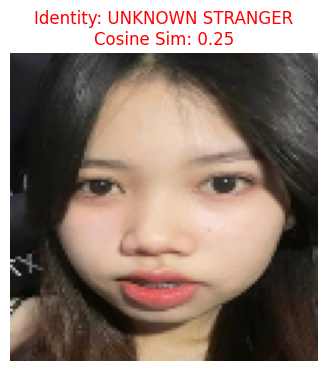

Target Processed    : /content/drive/MyDrive/pp_v2/test/ttt1.jpg
System Label Result : UNKNOWN STRANGER
Raw Score (No Bias) : 0.2472
🚨 Access Denied! Face falls completely outside known registry anchors.


In [31]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN

# ── 1. CONFIGURATION ─────────────────────────────────────────────────────────
# Change these paths to match your system files if necessary
TEST_IMAGE_PATH  = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"
OPENS_THRESHOLD  = 0.45  # 👈 Anyone below 0.45 cosine similarity is rejected

# ── 2. FACE ALIGNMENT & PREPROCESSING FUNCTION ────────────────────────────────
detector = MTCNN()

def align_and_crop_face(image_path, target_size=(112, 112)):
    """Loads an image, aligns the face horizontally using eyes, crops, and normalizes."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"❌ Cannot read image file at: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if not results:
        print('⚠️ No face detected by MTCNN — using resized original image instead.')
        aligned = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_LINEAR)
    else:
        # Pick face with the highest confidence score
        r = max(results, key=lambda x: x['confidence'])
        kp = r['keypoints']
        le, re = np.array(kp['left_eye']), np.array(kp['right_eye'])

        # Calculate angle to rotate face completely flat
        dy, dx = re[1] - le[1], re[0] - le[0]
        angle = np.degrees(np.arctan2(dy, dx))

        center = ((le[0] + re[0]) / 2, (le[1] + re[1]) / 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        h, w = img_rgb.shape[:2]
        rotated = cv2.warpAffine(img_rgb, M, (w, h), flags=cv2.INTER_LINEAR)

        # Crop face safely with 10% outer padding
        x, y, bw, bh = r['box']
        margin = int(max(bw, bh) * 0.10)
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(w, x + bw + margin)
        y2 = min(h, y + bh + margin)

        face = rotated[y1:y2, x1:x2]
        if face.size == 0:
            aligned = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_LINEAR)
        else:
            aligned = cv2.resize(face, target_size, interpolation=cv2.INTER_LINEAR)

    # ── Critical ArcFace Normalization ──
    # Cast pixels to floats and squeeze them precisely to the [-1.0, 1.0] range
    img_normalized = (aligned.astype(np.float32) - 127.5) / 128.0
    return img_normalized, aligned


# ── 3. OPEN-SET EVALUATION SYSTEM ─────────────────────────────────────────────
def run_open_set_inference(image_path, trained_model, classes, total_classes, threshold=0.45):
    """Predicts person name using pure geometric Cosine Similarity. Rejects strangers."""
    # Preprocess image
    img_norm, img_display = align_and_crop_face(image_path)
    img_batch = np.expand_dims(img_norm, axis=0)

    # Create empty mock arrays to satisfy our multi-input training layout requirements
    dummy_labels = np.zeros((1, total_classes), dtype=np.float32)

    # Run predictions through our fine-tuned network structure
    logits = trained_model(
        {'input_image': img_batch, 'input_labels': dummy_labels},
        training=False  # Crucial: forces custom ArcFace layer to drop the training margin penalty
    )

    # ── NO CHEATING WITH SOFTMAX ──
    # Divide out the scaling parameter (s=64) to get clean, native Cosine Similarities (-1 to 1)
    raw_cosines = logits.numpy() / 64.0

    # Locate maximum match vector index
    pred_idx = np.argmax(raw_cosines)
    highest_similarity = float(raw_cosines[0][pred_idx])

    # Apply Open-Set Decision boundary check
    if highest_similarity >= threshold:
        predicted_identity = classes[pred_idx]
        is_known = True
    else:
        predicted_identity = "UNKNOWN STRANGER"
        is_known = False

    return predicted_identity, highest_similarity, is_known, img_display


# ── 4. EXECUTE & DISPLAY TEST ──────────────────────────────────────────────────
try:
    pred_name, sim_score, is_authorized, display_img = run_open_set_inference(
        image_path=TEST_IMAGE_PATH,
        trained_model=model,        # Uses 'model' variable active in your current notebook RAM
        classes=CLASS_NAMES,        # Uses 'CLASS_NAMES' variable active in notebook RAM
        total_classes=NUM_CLASSES,  # Uses 'NUM_CLASSES' variable active in notebook RAM
        threshold=OPENS_THRESHOLD
    )

    # Visual Output Display using Matplotlib
    plt.figure(figsize=(4, 4))
    plt.imshow(display_img)
    text_color = 'green' if is_authorized else 'red'
    plt.title(f'Identity: {pred_name}\nCosine Sim: {sim_score:.2f}', fontsize=12, color=text_color)
    plt.axis('off')
    plt.show()

    # Terminal Log Prints
    print(f"Target Processed    : {TEST_IMAGE_PATH}")
    print(f"System Label Result : {pred_name}")
    print(f"Raw Score (No Bias) : {sim_score:.4f}")
    if not is_authorized:
        print("🚨 Access Denied! Face falls completely outside known registry anchors.")

except Exception as error:
    print(f"❌ Execution failed! Error details: {error}")
    print("Double check that your global variables 'model', 'CLASS_NAMES', and 'NUM_CLASSES' exist in memory.")


## Step 14 — Inference (Single Image Prediction)

At inference the `input_labels` is a dummy zero tensor — the ArcFace layer
detects `training=False` and skips the margin, returning plain cosine × scale.

In [ ]:
import cv2
import numpy as np
from mtcnn import MTCNN
from PIL import Image
import shutil

detector = MTCNN()
def align_and_crop(img_bgr, target_size=(112, 112)):
    """
    Detect face, align by rotating so eyes are horizontal, crop tightly.
    Returns aligned RGB image (HxWx3 uint8) or None if no face found.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if not results:
        return None  # No face detected — skip this image

    # Use the detection with highest confidence
    r = max(results, key=lambda x: x['confidence'])

    # ── Alignment: rotate so eyes are horizontal ──────────────────────────────
    kp    = r['keypoints']
    le, re = np.array(kp['left_eye']), np.array(kp['right_eye'])
    dy, dx = re[1] - le[1], re[0] - le[0]
    angle  = np.degrees(np.arctan2(dy, dx))

    center = ((le[0] + re[0]) / 2, (le[1] + re[1]) / 2)
    M      = cv2.getRotationMatrix2D(center, angle, 1.0)
    h, w   = img_rgb.shape[:2]
    rotated = cv2.warpAffine(img_rgb, M, (w, h), flags=cv2.INTER_LINEAR)

    # ── Crop: use bounding box from original detection ────────────────────────
    x, y, bw, bh = r['box']
    # Add 10% margin on each side so we don't cut ears
    margin = int(max(bw, bh) * 0.10)
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(w, x + bw + margin)
    y2 = min(h, y + bh + margin)

    face = rotated[y1:y2, x1:x2]
    if face.size == 0:
        return None

    # ── Resize to ArcFace native 112×112 ──────────────────────────────────────
    face_resized = cv2.resize(face, target_size, interpolation=cv2.INTER_LINEAR)
    return face_resized  # RGB uint8

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


TEST_IMAGE = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"

def align_single_image(image_path, target_size=(112, 112)):
    """Align and normalize a single test image exactly like training data."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read: {image_path}')
    aligned = align_and_crop(img_bgr, target_size)
    if aligned is None:
        print('⚠️  No face detected — using resized original')
        aligned = cv2.resize(
            cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
            target_size
        )
    # Normalize to [-1, 1] — ArcFace standard
    img_float = (aligned.astype(np.float32) - 127.5) / 128.0
    return img_float, aligned   # normalized + display copy


def predict_person(image_path, model, class_names, num_classes):

    img_norm, img_display = align_single_image(image_path)

    img_batch = np.expand_dims(img_norm, axis=0)

    dummy_labels = np.zeros((1, num_classes), dtype=np.float32)

    logits = model(
        {
            'input_image': img_batch,
            'input_labels': dummy_labels
        },
        training=False
    )

    probs = tf.nn.softmax(logits, axis=1).numpy()

    pred_idx = np.argmax(probs[0])

    confidence = float(probs[0][pred_idx])

    pred_name = class_names[pred_idx]

    return pred_name, confidence, img_display


# ── Run prediction ────────────────────────────────────────────────────────────
pred_name, confidence, display_img = predict_person(
    TEST_IMAGE, model, CLASS_NAMES, NUM_CLASSES
)

plt.figure(figsize=(4, 4))
plt.imshow(display_img)
color = 'green' if confidence > 0.7 else ('orange' if confidence > 0.4 else 'red')
plt.title(
    f'Predicted : {pred_name}\nConfidence: {confidence*100:.1f}%',
    fontsize=12, color=color
)
plt.axis('off')
plt.show()

print(f'Predicted  : {pred_name}')
print(f'Confidence : {confidence*100:.2f}%')
if confidence < 0.4:
    print('⚠️  Low confidence — consider more training data for this person.')

## Step 12 — Training Curves

In [ ]:
import matplotlib.pyplot as plt

def plot_history(h1, h2, metric='acc'):
    v1 = h1.history[metric]
    vv1 = h1.history[f'val_{metric}']
    v2 = h2.history[metric]
    vv2 = h2.history[f'val_{metric}']

    ep1 = range(1, len(v1) + 1)
    ep2 = range(len(v1) + 1, len(v1) + len(v2) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(ep1, v1,  'b-',  label='Ph1 train')
    plt.plot(ep1, vv1, 'b--', label='Ph1 val')
    plt.plot(ep2, v2,  'r-',  label='Ph2 train')
    plt.plot(ep2, vv2, 'r--', label='Ph2 val')
    plt.axvline(len(v1) + 0.5, color='gray', linestyle=':', label='Phase boundary')
    plt.xlabel('Epoch'); plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} over Training'); plt.legend()

    plt.subplot(1, 2, 2)
    loss1  = h1.history['loss']
    vloss1 = h1.history['val_loss']
    loss2  = h2.history['loss']
    vloss2 = h2.history['val_loss']
    plt.plot(ep1, loss1,  'b-',  label='Ph1 train')
    plt.plot(ep1, vloss1, 'b--', label='Ph1 val')
    plt.plot(ep2, loss2,  'r-',  label='Ph2 train')
    plt.plot(ep2, vloss2, 'r--', label='Ph2 val')
    plt.axvline(len(v1) + 0.5, color='gray', linestyle=':')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss over Training'); plt.legend()

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150)
    plt.show()
    print('✅ Saved to /content/training_curves.png')

plot_history(history_p1, history_p2)